In [2]:
#Biblioteki
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.stats import shapiro, normaltest, anderson
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
train = pd.read_csv('train.csv')

print(train.head(5))
print(train.info())
print(train.describe())  #statystyki dla kolumn numerycznych

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

Opis cech: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [4]:
#Analiza brakujących danych, duplikatów i typów zmiennych
print("Brakujące wartości:")
print(train.isnull().sum().sort_values(ascending=False).head(20))
print("\nLiczba duplikatów:", train.duplicated().sum())
print("\nTypy zmiennych:")
print(train.dtypes.value_counts())

Brakujące wartości:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

Liczba duplikatów: 0

Typy zmiennych:
object     43
int64      35
float64     3
Name: count, dtype: int64


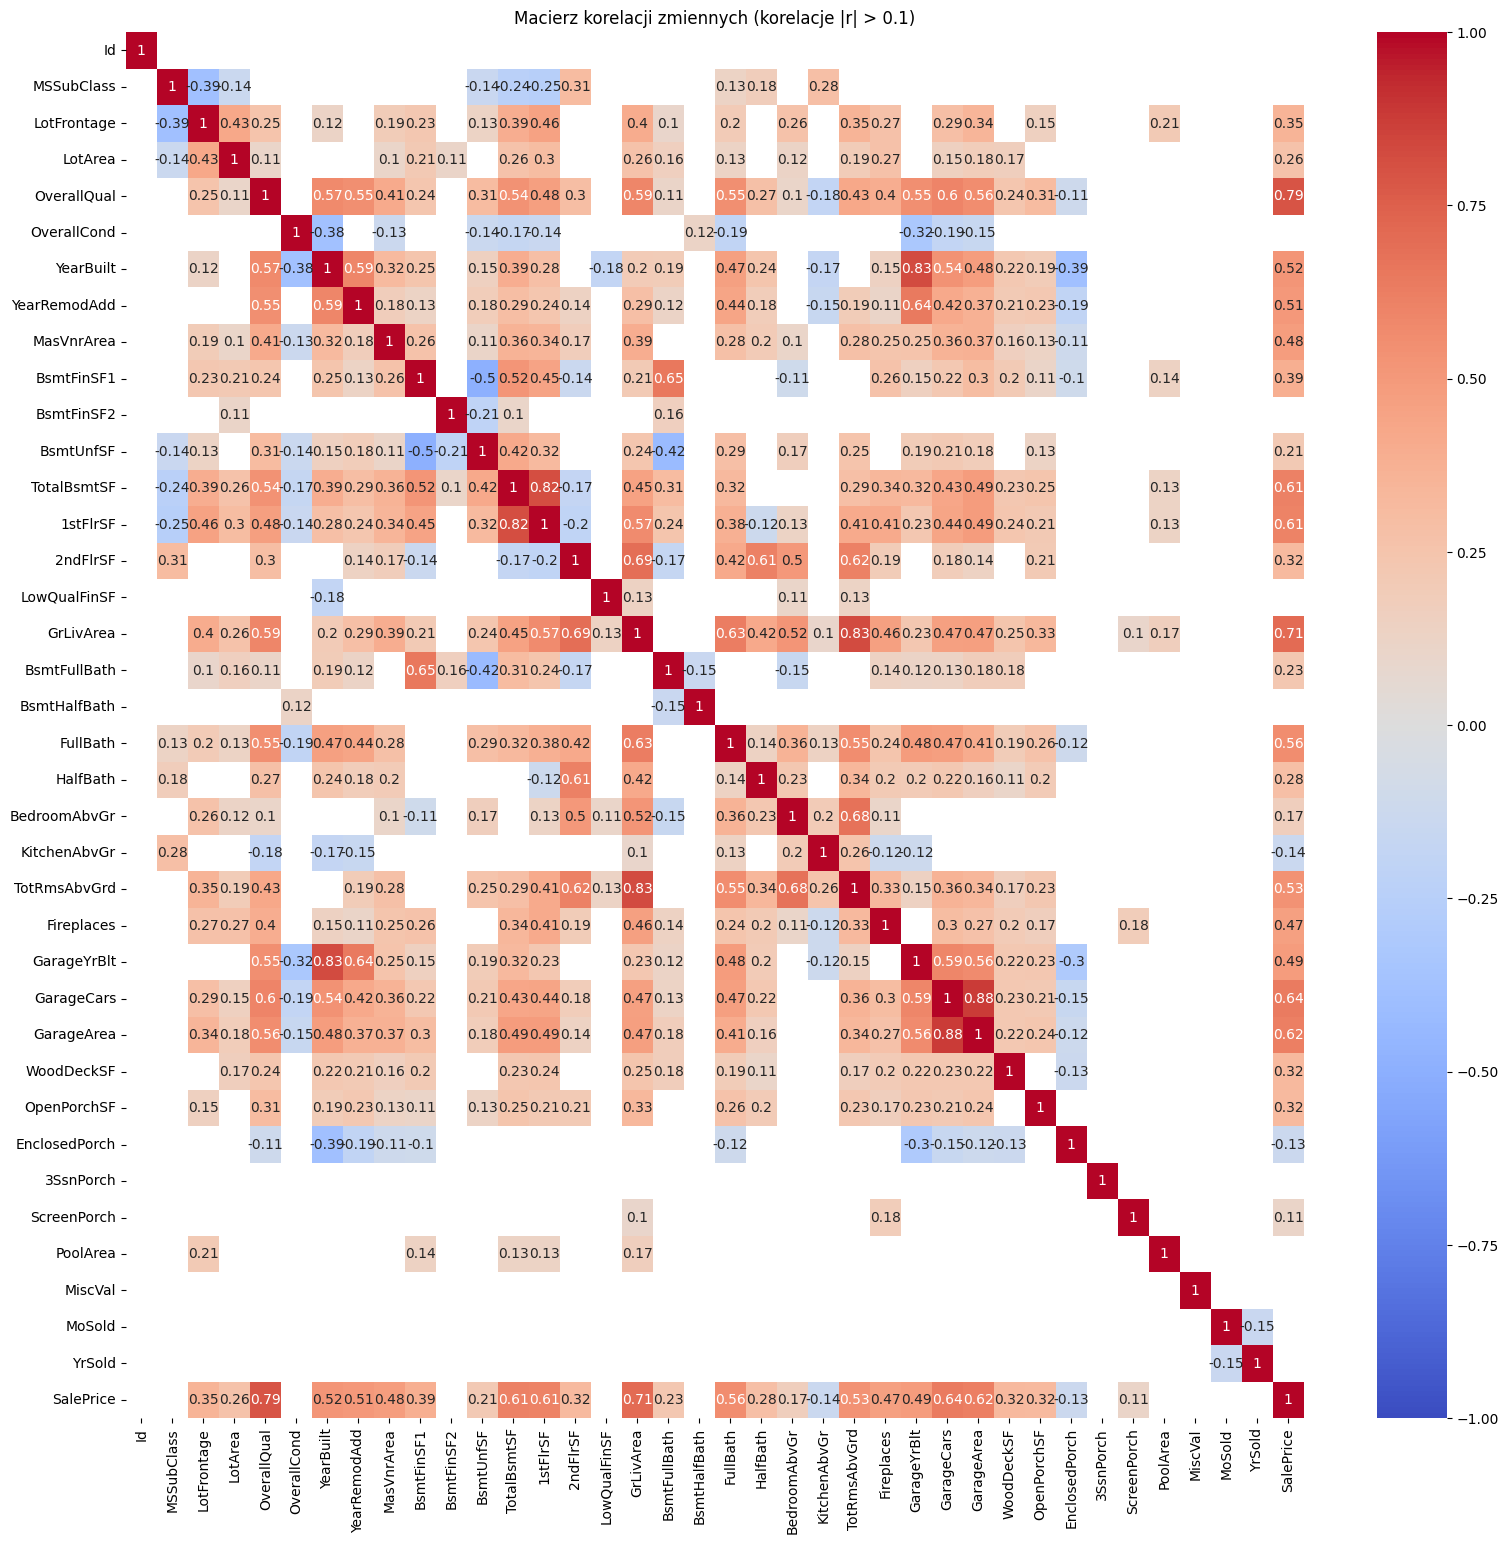

In [10]:
#Macierz korelacji cech numerycznych
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

plt.figure(figsize=(19,18))
sns.heatmap(corr_matrix[(corr_matrix > 0.1) | (corr_matrix < -0.1)],
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Macierz korelacji zmiennych (korelacje |r| > 0.1)")
plt.show()

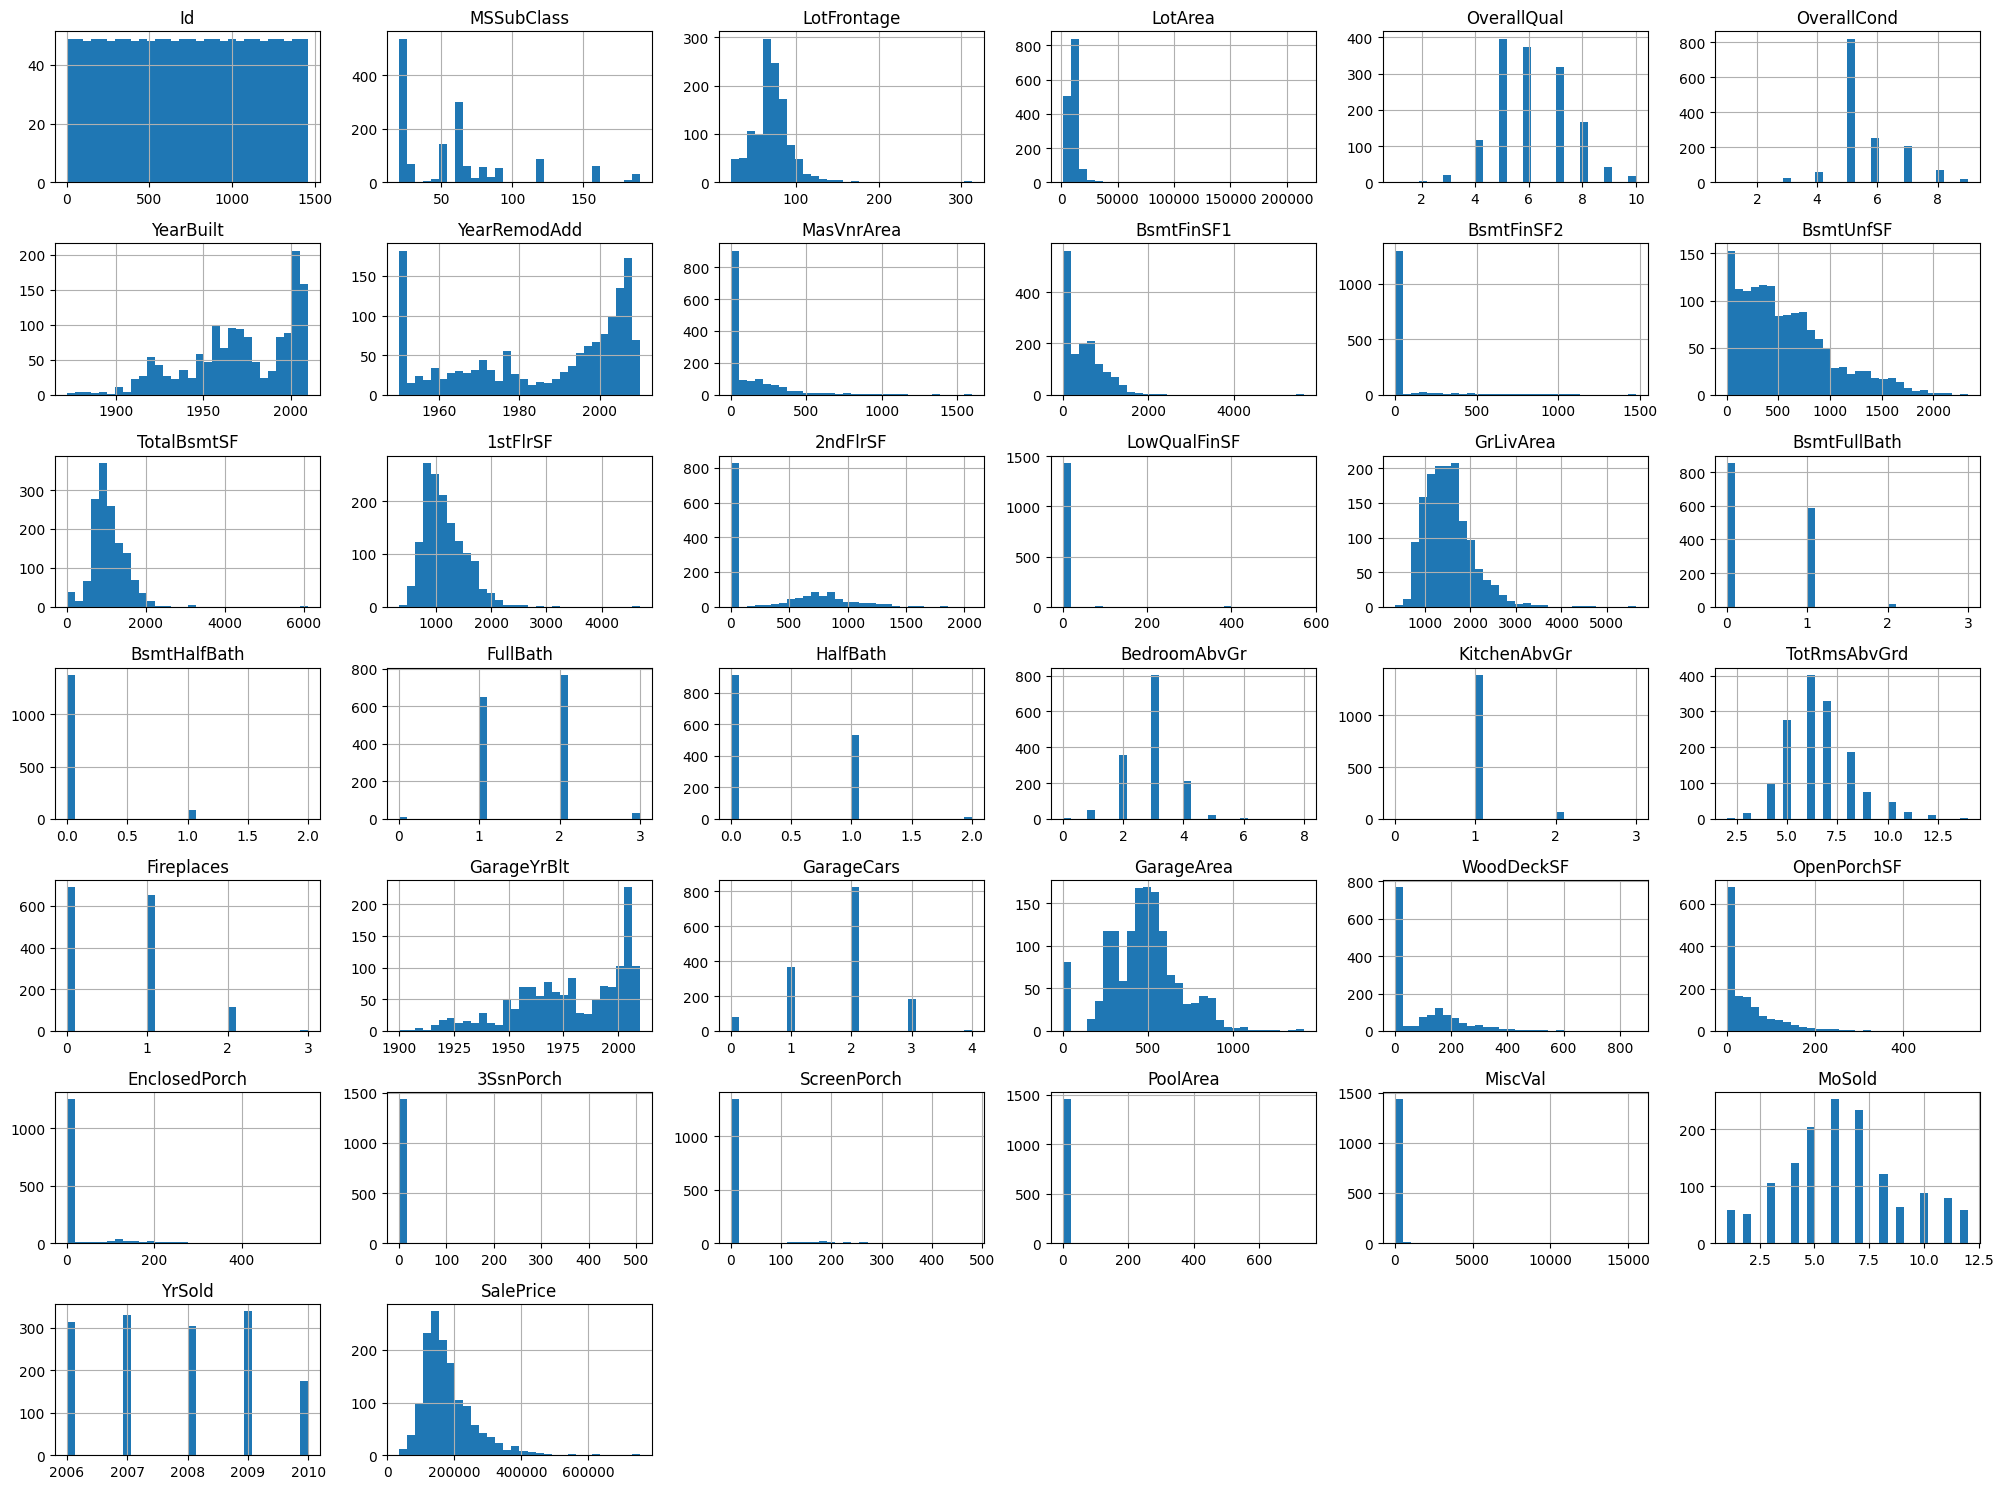

In [ ]:
#Histogramy cech numerycznych
train[numeric_cols].hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

In [6]:
# Testy normalności dla wybranych cech numerycznych
test_columns = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt']
for column in test_columns:
    print(f"\nCecha: {column}")

    if train[column].notna().sum() < 3:
        print("Za mało danych do testu")
        continue

    #Shapiro-Wilk
    stat_sw, p_sw = shapiro(train[column].dropna())
    print(f"  Shapiro-Wilk: stat={stat_sw:.4f}, p={p_sw:.4f} --> {'normalny' if p_sw > 0.05 else 'nienormalny'}")

    #D'Agostino Pearson
    stat_dp, p_dp = normaltest(train[column].dropna())
    print(f"  D'Agostino-Pearson: stat={stat_dp:.4f}, p={p_dp:.4f} --> {'normalny' if p_dp > 0.05 else 'nienormalny'}")

    #Anderson-Darling
    result_ad = anderson(train[column].dropna(), dist='norm')
    ad_stat = result_ad.statistic
    ad_crit_val = result_ad.critical_values[2]
    print(f"  Anderson-Darling: stat={ad_stat:.4f}, crit(5%)={ad_crit_val:.4f} --> {'normalny' if ad_stat < ad_crit_val else 'nienormalny'}")
    print("-" * 50)


Cecha: SalePrice
  Shapiro-Wilk: stat=0.8697, p=0.0000 --> nienormalny
  D'Agostino-Pearson: stat=610.8359, p=0.0000 --> nienormalny
  Anderson-Darling: stat=41.6920, crit(5%)=0.7850 --> nienormalny
--------------------------------------------------

Cecha: GrLivArea
  Shapiro-Wilk: stat=0.9280, p=0.0000 --> nienormalny
  D'Agostino-Pearson: stat=437.1203, p=0.0000 --> nienormalny
  Anderson-Darling: stat=14.5322, crit(5%)=0.7850 --> nienormalny
--------------------------------------------------

Cecha: TotalBsmtSF
  Shapiro-Wilk: stat=0.9174, p=0.0000 --> nienormalny
  D'Agostino-Pearson: stat=622.8951, p=0.0000 --> nienormalny
  Anderson-Darling: stat=17.2764, crit(5%)=0.7850 --> nienormalny
--------------------------------------------------

Cecha: OverallQual
  Shapiro-Wilk: stat=0.9480, p=0.0000 --> nienormalny
  D'Agostino-Pearson: stat=11.9046, p=0.0026 --> nienormalny
  Anderson-Darling: stat=35.2300, crit(5%)=0.7850 --> nienormalny
--------------------------------------------

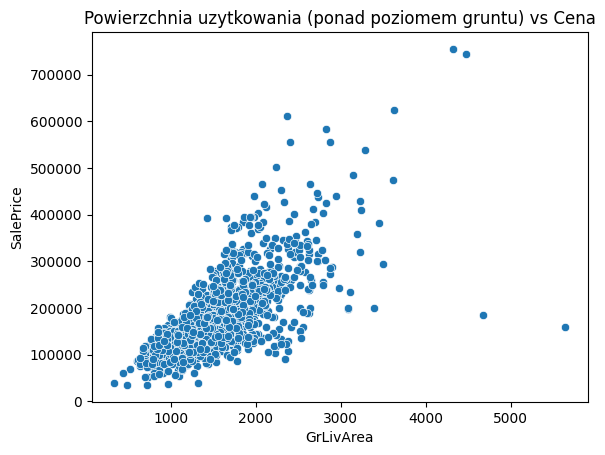

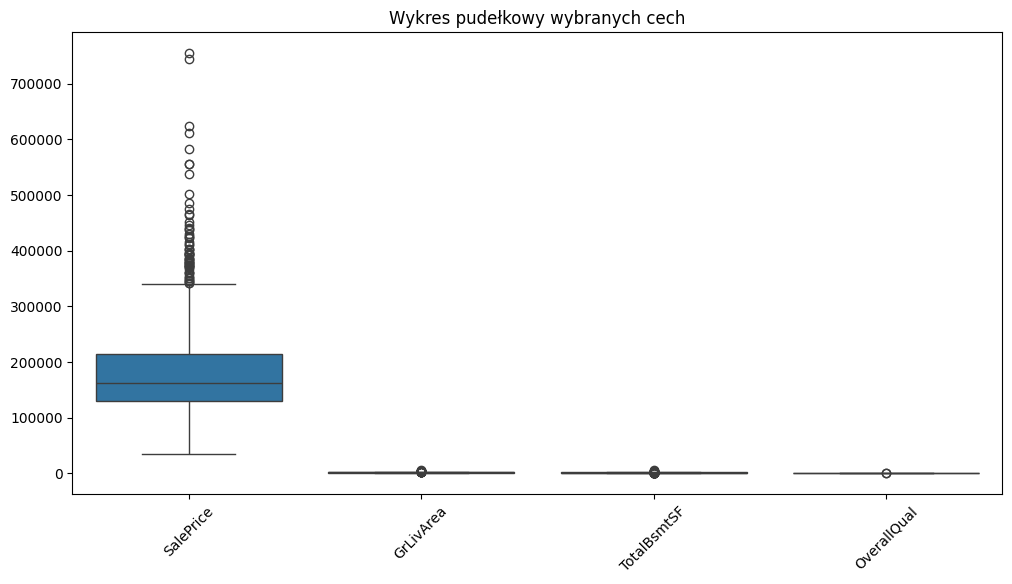

In [9]:
# Wykres punktowy dla powierzchni użytkowania a ceną
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.title('Powierzchnia uzytkowania (ponad poziomem gruntu) vs Cena')
plt.show()

#Wykres pudełkowy dla wybranych cech numerycznych w obencym stanie
plt.figure(figsize=(12,6))
sns.boxplot(data=train[['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual']])
plt.title('Wykres pudełkowy wybranych cech')
plt.xticks(rotation=45)
plt.show()

**Wnioski na podstawie analizy danych:**

Zbiór zawiera 1460 obserwacji i 81 cech (w tym zmienną docelową 'SalePrice')

Wyróżniamy następujące typy zmiennych:

- 43 cechy numeryczne (w tym całkowitoliczbowe jak 'OverallQual')

- 38 cech kategorycznych

Brakujące wartości występują w wielu kolumnach. Najwięcej występuje w cechach:

- PoolQC: 1453 brakujących (99.5%)

- MiscFeature: 1406 brakujących (96.3%)

- Alley: 1369 brakujących (93.8%)

- Fence: 1179 brakujących (80.7%)

- FireplaceQu: 690 brakujących (47.3%)

W danych nie występują duplikaty.

**Rozkład danych:**

Zmienna docelowa (SalePrice) ma rozkład prawoskośny (testy normalności nie wskazują na normalność)

Większość cech numerycznych nie ma rozkładu normalnego. Wartości odstające są widoczne przykładowo w:
- GrLivArea (powierzchnia mieszkalna powyżej 4000 sqft)

- TotalBsmtSF (powierzchnia piwnicy powyżej 3000 sqft)

- SalePrice (ceny powyżej 500000$)

Najsilniejsze korelacje z SalePrice posiadają cechy:

- OverallQual: 0.79 (jakość materiałów i wykończenia)

- GrLivArea: 0.71 (powierzchnia mieszkalna)

- GarageCars: 0.64 (wielkość garażu)

- GarageArea: 0.62 (powierzchnia garażu)

- TotalBsmtSF: 0.61 (powierzchnia piwnicy)

Inne silne korelacje między cechami dotyczą:

- GarageCars i GarageArea: 0.88

- TotalBsmtSF i 1stFlrSF: 0.82

- GrLivArea i TotRmsAbvGrd: 0.83

In [ ]:
# plt.scatter(x='GrLivArea', y='SalePrice', data=train)# > 4200
# plt.scatter(x='LotFrontage', y='SalePrice', data=train)# > 250
# plt.scatter(x='LotArea', y='SalePrice', data=train)# > 50000
# plt.scatter(x='OverallCond', y='SalePrice', data=train)# == 2, == 5 where SalePrice > 700000, == 6 where SalePrice > 700000
# plt.scatter(x='BsmtFinSF1', y='SalePrice', data=train)# > 5000
# plt.scatter(x='MasVnrArea', y='SalePrice', data=train)# > 1400
# plt.scatter(x='LowQualFinSF', y='SalePrice', data=train)# > 530
# plt.scatter(x='BsmtFinSF2', y='SalePrice', data=train)# > 1200, > 400 where SalePrice > 500000
# plt.scatter(x='TotalBsmtSF', y='SalePrice', data=train)# > 5000
# plt.scatter(x='BsmtFullBath', y='SalePrice', data=train)# == 3
# plt.scatter(x='BsmtHalfBath', y='SalePrice', data=train)# == 2
# plt.scatter(x='BedroomAbvGr', y='SalePrice', data=train)# > 7
# plt.scatter(x='KitchenAbvGr', y='SalePrice', data=train)# == 3
# plt.scatter(x='TotRmsAbvGrd', y='SalePrice', data=train)#  > 13
# plt.scatter(x='GarageArea', y='SalePrice', data=train)#  > 1200
# plt.scatter(x='WoodDeckSF', y='SalePrice', data=train)#  > 800
# plt.scatter(x='OpenPorchSF ', y='SalePrice', data=train)#  > 500
# plt.scatter(x='EnclosedPorch ', y='SalePrice', data=train)#  > 500

In [ ]:
#1. Usuwanie wartości odstających
def remove_outliers(df):
    original_size = len(df)

    #warunki do usunięcia
    conditions = [
        df['GrLivArea'] > 4200,
        df['LotFrontage'] > 250,
        df['LotArea'] > 50000,
        df['OverallCond'] == 2,
        (df['OverallCond'] == 5) & (df['SalePrice'] > 700000),
        (df['OverallCond'] == 6) & (df['SalePrice'] > 700000),
        df['MasVnrArea'] > 1400,
        df['BsmtFinSF1'] > 5000,
        df['BsmtFinSF2'] > 1200,
        (df['BsmtFinSF2'] > 400) & (df['SalePrice'] > 500000),
        df['TotalBsmtSF'] > 5000,
        df['LowQualFinSF'] > 530,
        df['BsmtFullBath'] == 3,
        df['BsmtHalfBath'] == 2,
        df['BedroomAbvGr'] > 7,
        df['KitchenAbvGr'] == 3,
        df['TotRmsAbvGrd'] > 13,
        df['GarageArea'] > 1200,
        df['WoodDeckSF'] > 800,
        df['OpenPorchSF'] > 500,
        df['EnclosedPorch'] > 500
    ]

    combined_condition = conditions[0]
    for cond in conditions[1:]:
        combined_condition = combined_condition | cond

    df_clean = df[~combined_condition] #usuwanie odpowiednich wartości o danych warunkach
    #Informacja o usuniętych obserwacjach
    removed_count = original_size - len(df_clean)
    print(f"Usunięto {removed_count} obserwacji ({removed_count/original_size:.2%} danych)")
    return df_clean

train_clean = remove_outliers(train)

Usunięto 38 obserwacji (2.60% danych)


In [ ]:
#2. Obsługa brakujących danych
def delete_missing_data(df):
    cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType', 'GarageArea']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    return df

train_processed = delete_missing_data(train_clean)

In [ ]:
#3. Edycja cech z mniejszą ilością brakujących danych
def handle_missing_data(df):

    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
    df['GarageType'] = df['GarageType'].fillna('No')
    df['GarageFinish'] = df['GarageFinish'].fillna('No')
    df['GarageQual'] = df['GarageQual'].fillna('No')
    df['BsmtQual'] = df['BsmtQual'].fillna('No')
    df['BsmtCond'] = df['BsmtCond'].fillna('No')
    df['BsmtExposure'] = df['BsmtExposure'].fillna('No')
    df['BsmtFinType1'] = df['BsmtFinType1'].fillna('Unf')
    df['Electrical'] = df['Electrical'].fillna('SBrkr')
    df['LotFrontage'] = df['LotFrontage'].fillna(0)

    #Strategie dla pozostałych kolumn
    #Numeryczne - mediana
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df[col].isnull().sum() > 0 and col not in ['MasVnrArea', 'LotFrontage']:
            df[col] = df[col].fillna(df[col].median())

    #Kategoryczne - najczęstsza wartość
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df[col].isnull().sum() > 0 and col not in ['GarageType', 'GarageFinish', 'GarageQual', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1']:
            df[col] = df[col].fillna(df[col].mode()[0])

    return df

train_processed = handle_missing_data(train_processed)

In [ ]:
train_processed['SalePrice_log'] = np.log1p(train_processed['SalePrice'])

#4. Przekształcene zmiennych kategorycznych na liczbowe (One-Hot encoding)
def encode_categorical(df):
    cat_cols = [col for col in df.select_dtypes(include=['object']).columns
                if df[col].nunique() > 1]

    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df_encoded

train_encoded = encode_categorical(train_processed)

#5. Standaryzacja cech numerycznych
def standardize_features(df, target_col='SalePrice_log'):
    if target_col in df.columns:
        target = df[target_col].copy()  #kopia wartości docelowej i ID aby je zachować
        df = df.drop(columns=[target_col, 'SalePrice'], errors='ignore')
    else:
        target = None

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    #przywracanie zmiennej docelowej
    if target is not None:
        df[target_col] = target

    return df, scaler

train_final, scaler = standardize_features(train_encoded)


Ostateczny rozmiar zbioru treningowego: (1137, 228)
Ostateczny rozmiar zbioru testowego: (285, 228)


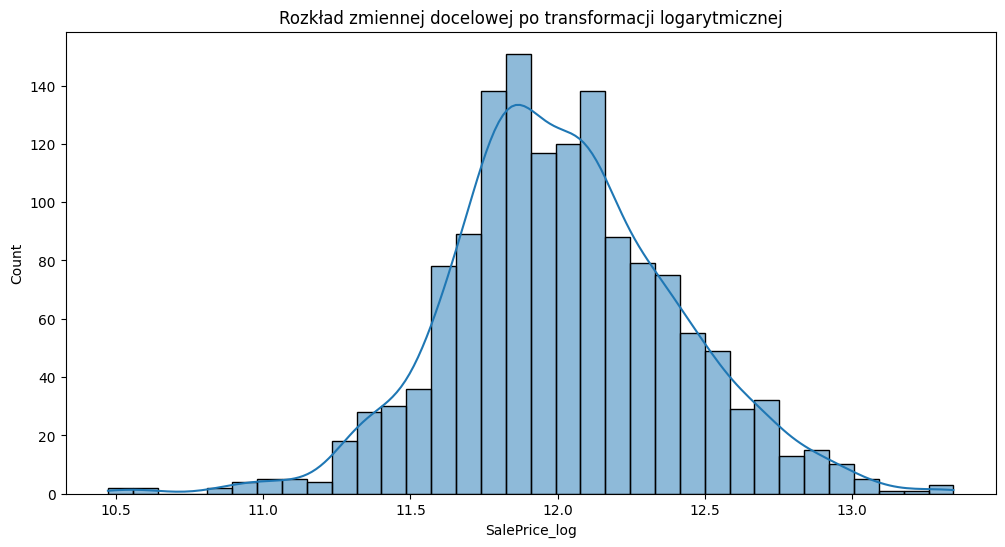

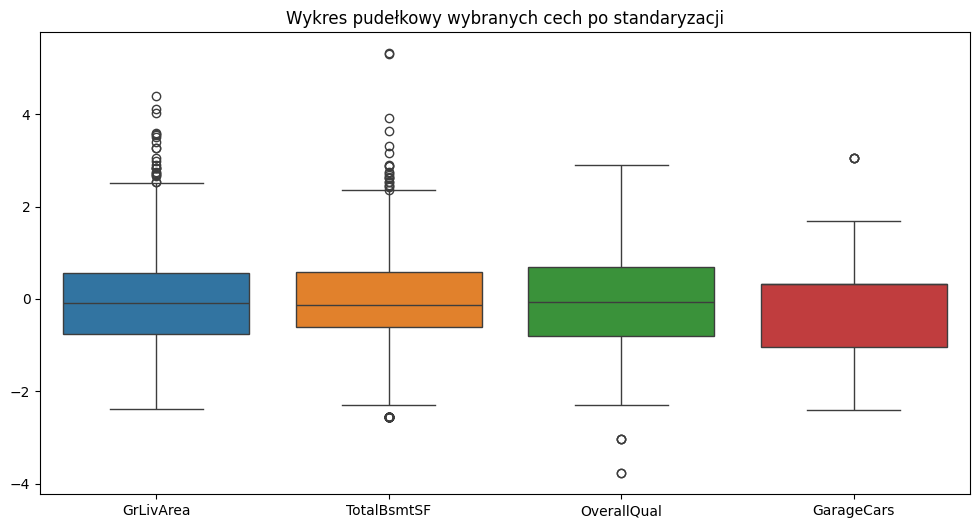

In [ ]:
X = train_final.drop(columns=['Id', 'SalePrice_log'], errors='ignore')
y = train_final['SalePrice_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nOstateczny rozmiar zbioru treningowego: {X_train.shape}")
print(f"Ostateczny rozmiar zbioru testowego: {X_test.shape}")

plt.figure(figsize=(12,6))
sns.histplot(train_final['SalePrice_log'], kde=True)
plt.title('Rozkład zmiennej docelowej po transformacji logarytmicznej')
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=train_final[['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'GarageCars']])
plt.title('Wykres pudełkowy wybranych cech po standaryzacji')
plt.show()

Porównanie modeli:
            Random Forest  Gradient Boosting
Train MSE          0.0319             0.0180
Test MSE           0.0405             0.0234
Train RMSE         0.1787             0.1343
Test RMSE          0.2011             0.1529
Train MAE          0.1258             0.0954
Test MAE           0.1370             0.1017
Train R2           0.7828             0.8773
Test R2            0.7478             0.8543


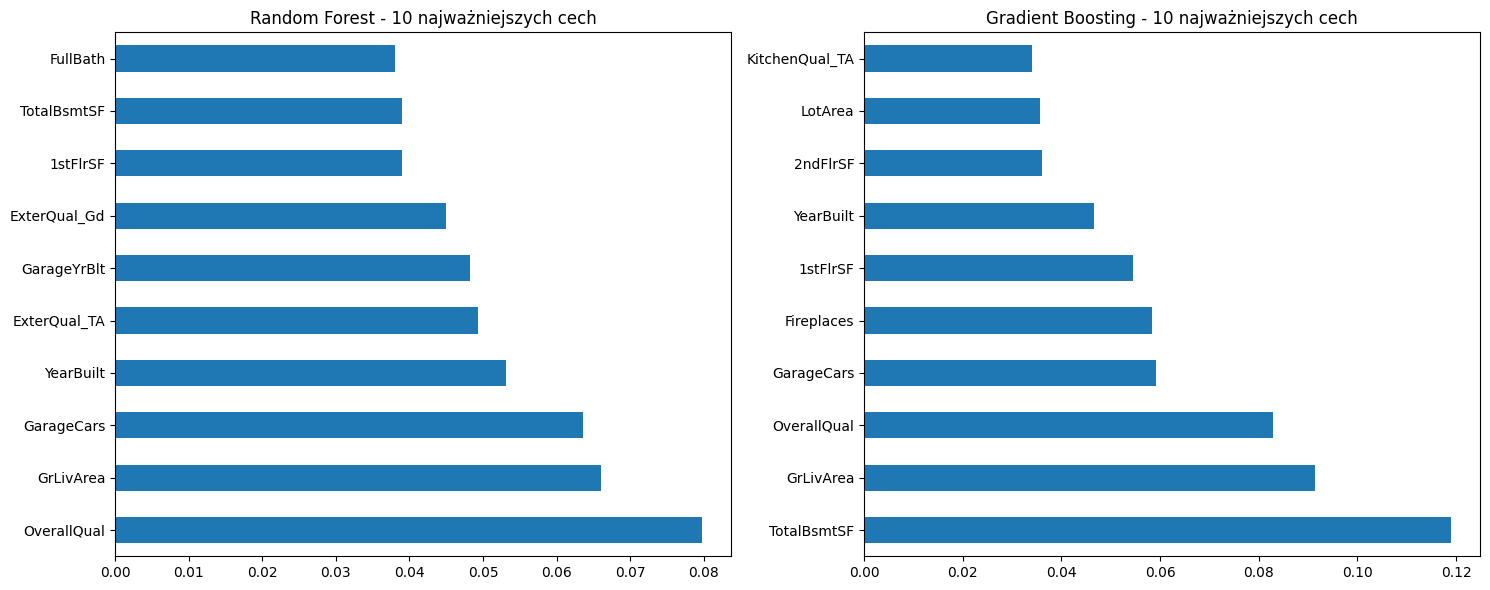

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Obliczanie metryk
    metrics = {
        'Train MSE': mean_squared_error(y_train, y_train_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred)
    }

    return metrics

#Random Forest
rf_model = RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='sqrt'
)

rf_model.fit(X_train, y_train)
rf_metrics = evaluate_model(rf_model, X_train, y_train, X_test, y_test)

#Gradient Boosting
gb_model = GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='sqrt'
)

gb_model.fit(X_train, y_train)
gb_metrics = evaluate_model(gb_model, X_train, y_train, X_test, y_test)


results = pd.DataFrame({
    'Random Forest': rf_metrics,
    'Gradient Boosting': gb_metrics
})

print("Porównanie modeli:")
print(results.round(4))

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
rf_feature_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
rf_feature_imp.nlargest(10).plot(kind='barh')
plt.title('Random Forest - 10 najważniejszych cech')

plt.subplot(1, 2, 2)
gb_feature_imp = pd.Series(gb_model.feature_importances_, index=X_train.columns)
gb_feature_imp.nlargest(10).plot(kind='barh')
plt.title('Gradient Boosting - 10 najważniejszych cech')

plt.tight_layout()
plt.show()

In [ ]:
#Szukanie najlpeszych parametrów dla random Forest i Gradient Boosting
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=rf_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid=gb_params, cv=5, scoring='neg_mean_squared_error')
gb_grid.fit(X_train, y_train)

print("Najlepsze parametry Random Forest:", rf_grid.best_params_)
print("Najlepsze parametry Gradient Boosting:", gb_grid.best_params_)

Najlepsze parametry Random Forest: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Najlepsze parametry Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


Porównanie modeli:
            Random Forest  Gradient Boosting
Train MSE          0.0025             0.0059
Test MSE           0.0216             0.0167
Train RMSE         0.0503             0.0768
Test RMSE          0.1471             0.1292
Train MAE          0.0353             0.0565
Test MAE           0.0973             0.0883
Train R2           0.9828             0.9599
Test R2            0.8651             0.8959


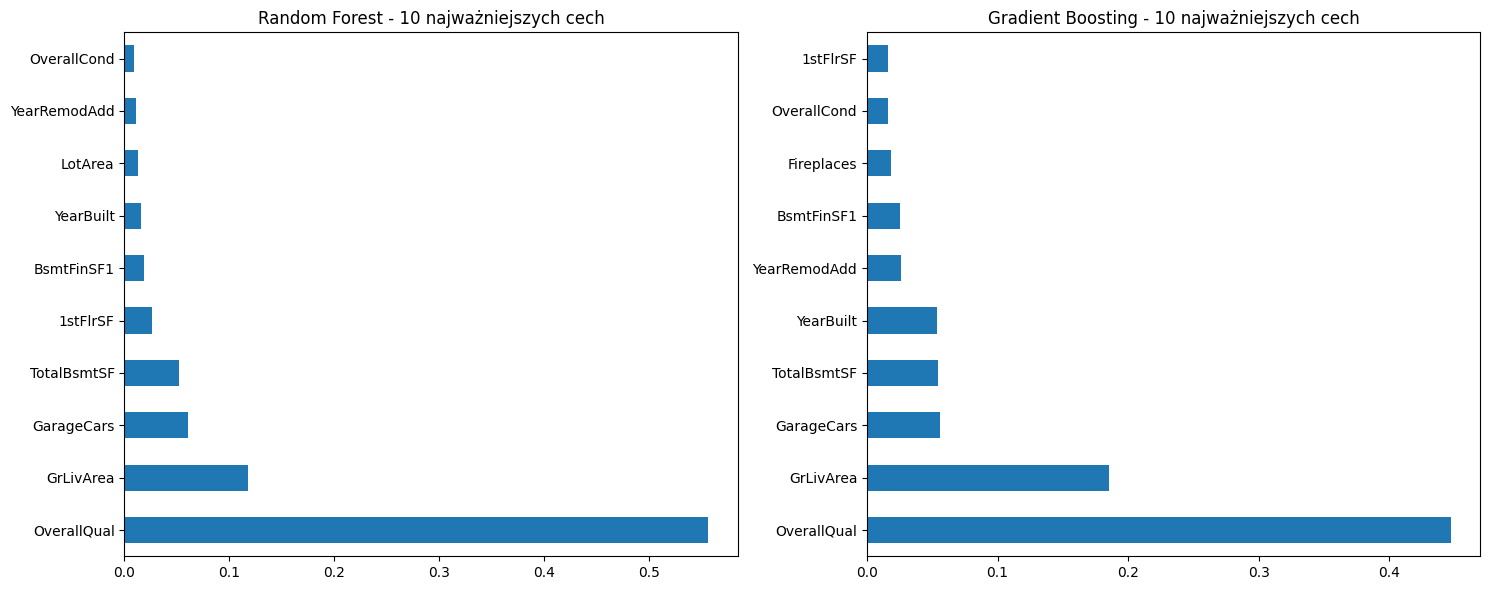

In [ ]:
def evaluate_model2(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'Train MSE': mean_squared_error(y_train, y_train_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred)
    }
    return metrics

rf_model = RandomForestRegressor(
      n_estimators=200,
      max_depth= 15,
      n_jobs=-1,
      min_samples_split= 2
)

rf_model.fit(X_train, y_train)
rf_metrics = evaluate_model2(rf_model, X_train, y_train, X_test, y_test)
gb_model = GradientBoostingRegressor(
      random_state=42,
      learning_rate= 0.05,
      max_depth= 3,
      n_estimators= 200
)

gb_model.fit(X_train, y_train)
gb_metrics = evaluate_model2(gb_model, X_train, y_train, X_test, y_test)

import pandas as pd

results = pd.DataFrame({
    'Random Forest': rf_metrics,
    'Gradient Boosting': gb_metrics
})

print("Porównanie modeli:")
print(results.round(4))

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
rf_feature_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
rf_feature_imp.nlargest(10).plot(kind='barh')
plt.title('Random Forest - 10 najważniejszych cech')

plt.subplot(1, 2, 2)
gb_feature_imp = pd.Series(gb_model.feature_importances_, index=X_train.columns)
gb_feature_imp.nlargest(10).plot(kind='barh')
plt.title('Gradient Boosting - 10 najważniejszych cech')

plt.tight_layout()
plt.show()

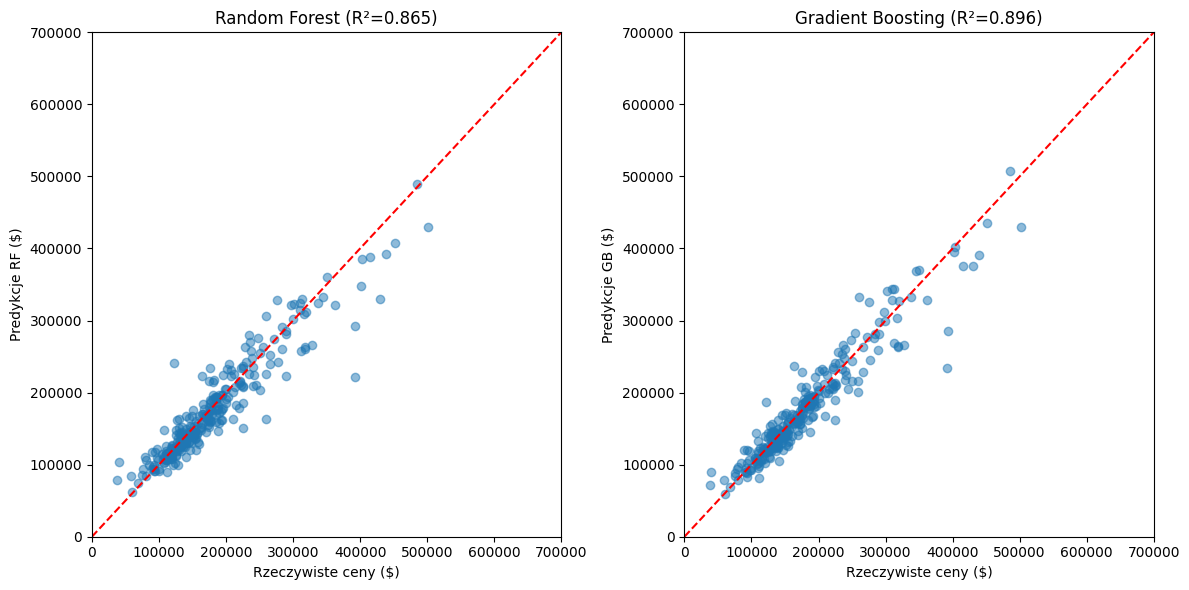

In [ ]:
#Wykres predykcji wobec rzeczywistych cen mieszkań

plt.figure(figsize=(12, 6))

#Random Forest
plt.subplot(1, 2, 1)
plt.scatter(np.expm1(y_test), np.expm1(rf_model.predict(X_test)), alpha=0.5)
plt.plot([0, 7e5], [0, 7e5], 'r--')
plt.xlabel('Rzeczywiste ceny ($)')
plt.ylabel('Predykcje RF ($)')
plt.title(f'Random Forest (R²={rf_metrics["Test R2"]:.3f})')
plt.xlim(0, 7e5)
plt.ylim(0, 7e5)

#Gradient Boosting
plt.subplot(1, 2, 2)
plt.scatter(np.expm1(y_test), np.expm1(gb_model.predict(X_test)), alpha=0.5)
plt.plot([0, 7e5], [0, 7e5], 'r--')
plt.xlabel('Rzeczywiste ceny ($)')
plt.ylabel('Predykcje GB ($)')
plt.title(f'Gradient Boosting (R²={gb_metrics["Test R2"]:.3f})')
plt.xlim(0, 7e5)
plt.ylim(0, 7e5)

plt.tight_layout()
plt.show()